In [2]:
from google.colab import files
uploaded = files.upload()

Saving Steel_industry_data.csv to Steel_industry_data.csv


In [3]:
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.5 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [4]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Clustering de series de tiempo
from tslearn.clustering import TimeSeriesKMeans, silhouette_score
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

# Evaluación
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

In [5]:
# Cargar el dataset
df = pd.read_csv('Steel_industry_data.csv')

# Exploración básica
print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nPrimeras filas:")
df.head()

Shape: (35040, 11)

Columnas: ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']

Primeras filas:


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [6]:
# Tipos de datos y nulos
print("Tipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())

Tipos de datos:
date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object

Valores nulos:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_T

In [7]:
# Estadísticas descriptivas
df.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


In [8]:
# Convertir columna date a datetime
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')

# Verificar rango temporal y frecuencia
print("Fecha inicio:", df['date'].min())
print("Fecha fin:   ", df['date'].max())
print("Total registros:", len(df))
print("Frecuencia:", df['date'].diff().mode()[0])
print("Días únicos:", df['date'].dt.date.nunique())

Fecha inicio: 2018-01-01 00:00:00
Fecha fin:    2018-12-31 23:45:00
Total registros: 35040
Frecuencia: 0 days 00:15:00
Días únicos: 365


In [9]:
# Seleccionar variables numéricas
variables = [
    'Usage_kWh',
    'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor'
]

# Agregar columna de fecha sin hora (solo el día)
df['day'] = df['date'].dt.date

# Verificar que cada día tenga exactamente 96 registros
registros_por_dia = df.groupby('day').size()
print("Registros por día (min):", registros_por_dia.min())
print("Registros por día (max):", registros_por_dia.max())
print("Días totales:", len(registros_por_dia))

Registros por día (min): 96
Registros por día (max): 96
Días totales: 365


In [10]:
# Ordenar por fecha
df = df.sort_values('date').reset_index(drop=True)

# Crear el array 3D (365 días x 96 puntos x 6 variables)
dias = df['day'].unique()

X = np.array([
    df[df['day'] == dia][variables].values
    for dia in dias
])

print("Shape del array:", X.shape)
# Esperado: (365, 96, 6)

Shape del array: (365, 96, 6)


In [11]:
# Guardar etiquetas categóricas por día (para validar clusters al final)
etiquetas_dia = df.groupby('day').agg(
    WeekStatus   = ('WeekStatus', 'first'),
    Day_of_week  = ('Day_of_week', 'first'),
    Load_Type    = ('Load_Type', lambda x: x.mode()[0])
).reset_index()

print(etiquetas_dia.head(7))

          day WeekStatus Day_of_week   Load_Type
0  2018-01-01    Weekday      Monday  Light_Load
1  2018-01-02    Weekday     Tuesday  Light_Load
2  2018-01-03    Weekday   Wednesday  Light_Load
3  2018-01-04    Weekday    Thursday  Light_Load
4  2018-01-05    Weekday      Friday  Light_Load
5  2018-01-06    Weekend    Saturday  Light_Load
6  2018-01-07    Weekend      Sunday  Light_Load


In [12]:
# Normalizar las series (media 0, varianza 1)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

print("Shape después de normalizar:", X_scaled.shape)
# Esperado: (365, 96, 6)

Shape después de normalizar: (365, 96, 6)


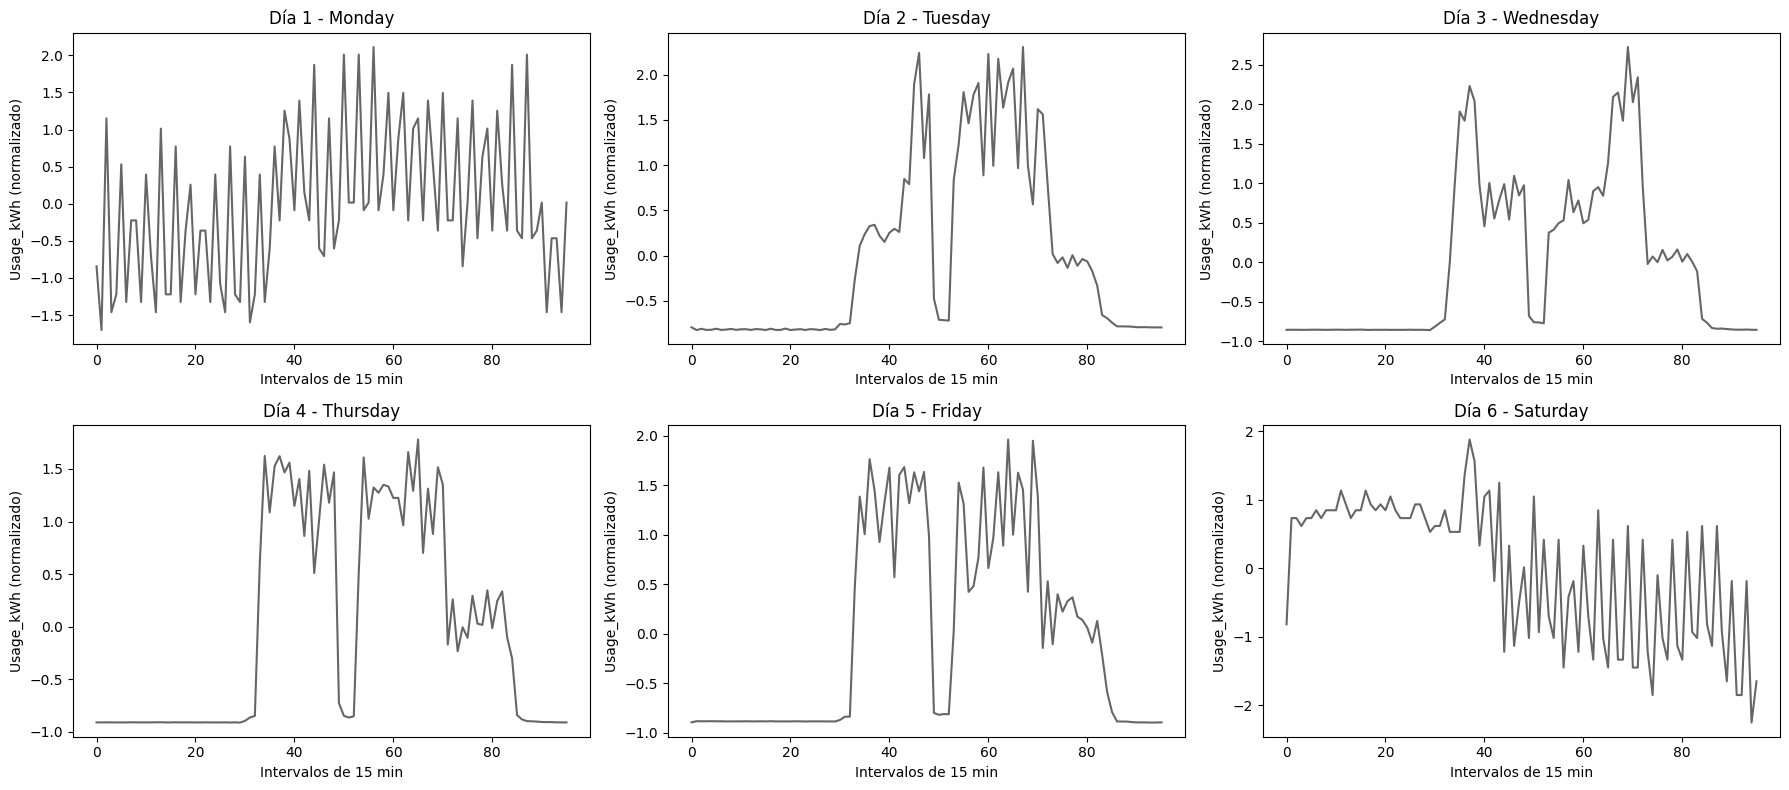

In [13]:
# Visualizar los primeros 6 días normalizados (solo Usage_kWh)
plt.figure(figsize=(18, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.plot(X_scaled[i, :, 0], "k-", alpha=0.6)
    plt.title(f"Día {i+1} - {etiquetas_dia['Day_of_week'][i]}")
    plt.xlabel("Intervalos de 15 min")
    plt.ylabel("Usage_kWh (normalizado)")
plt.tight_layout()
plt.show()

In [14]:
# Calcular inercia para k de 2 a 8
sum_of_squared_distances = []
K = range(2, 8)

for k in K:
    print(f"Entrenando con k={k}...")
    km = TimeSeriesKMeans(
        n_clusters=k,
        n_init=2,
        metric="dtw",
        verbose=False,
        max_iter_barycenter=10,
        random_state=0
    )
    km.fit(X_scaled)
    sum_of_squared_distances.append(km.inertia_)
    print(f"  Inercia: {km.inertia_:.2f}")

Entrenando con k=2...
  Inercia: 87.45
Entrenando con k=3...
  Inercia: 75.79
Entrenando con k=4...
  Inercia: 61.87
Entrenando con k=5...
  Inercia: 58.00
Entrenando con k=6...
  Inercia: 55.32
Entrenando con k=7...
  Inercia: 53.23


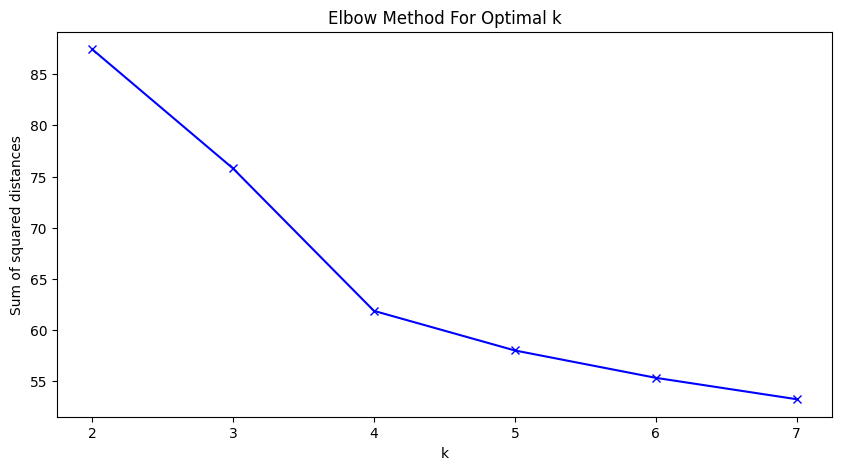

In [15]:
# Graficar el codo
plt.figure(figsize=(10, 5))
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum of squared distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Reshape para PCA (365 x 576) — aplanamos los 96 puntos x 6 variables
X_flat = X_scaled.reshape(X_scaled.shape[0], -1)

# Reducción de dimensionalidad con PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_flat)

print("Shape después de PCA:", X_pca.shape)
print("Componentes usados:", pca.n_components_)

Shape después de PCA: (365, 77)
Componentes usados: 77


Para n_clusters = 2, silhouette score = 0.32


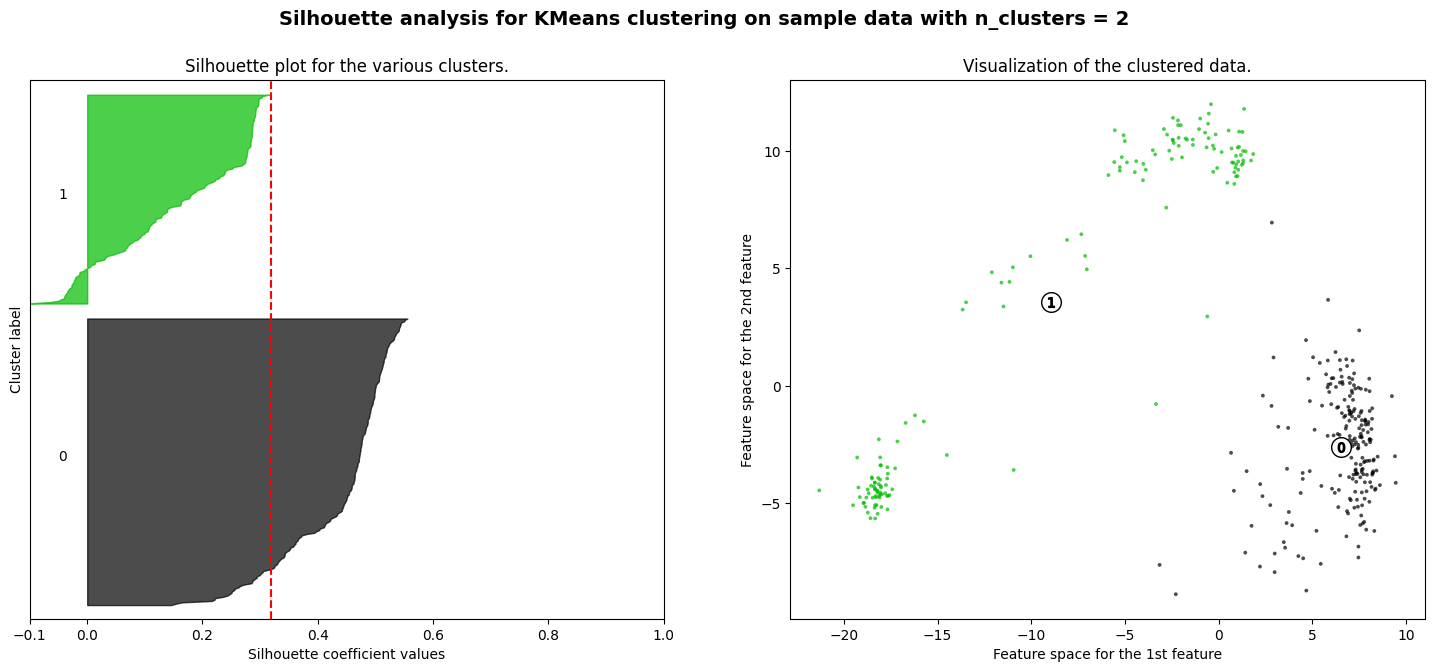

Para n_clusters = 3, silhouette score = 0.27


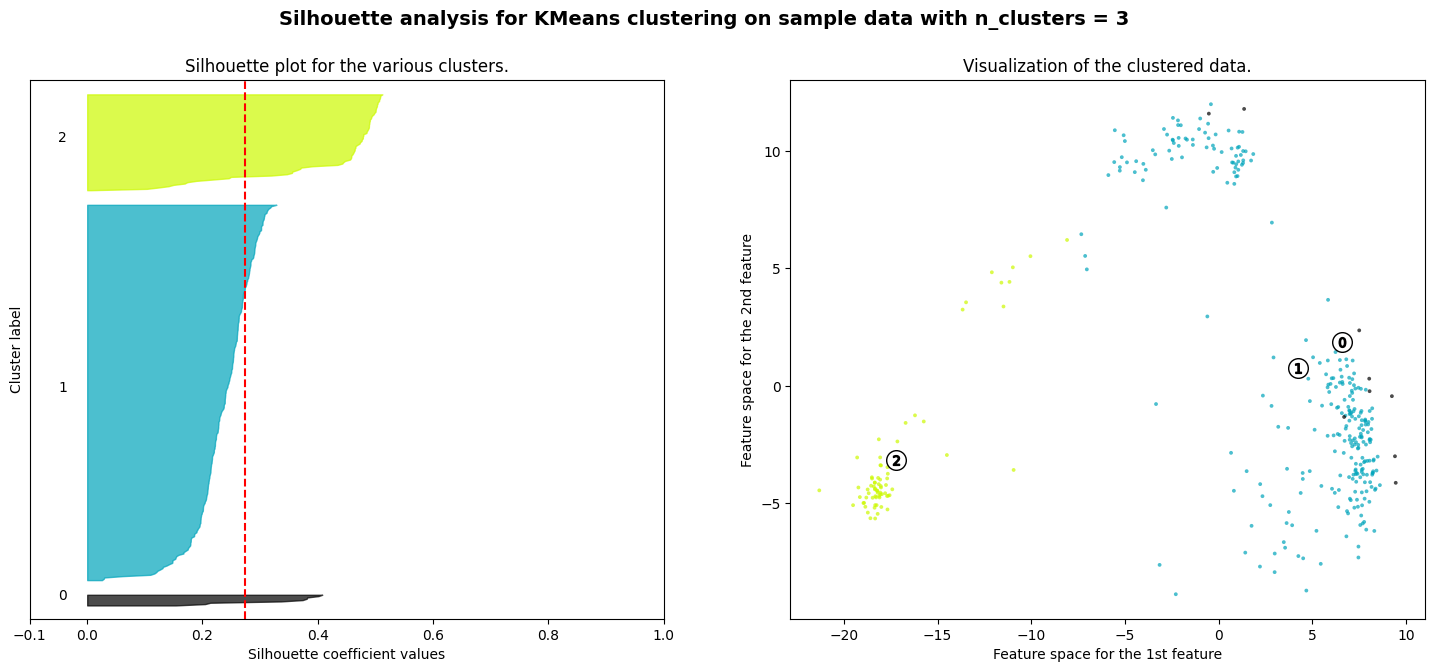

Para n_clusters = 4, silhouette score = 0.33


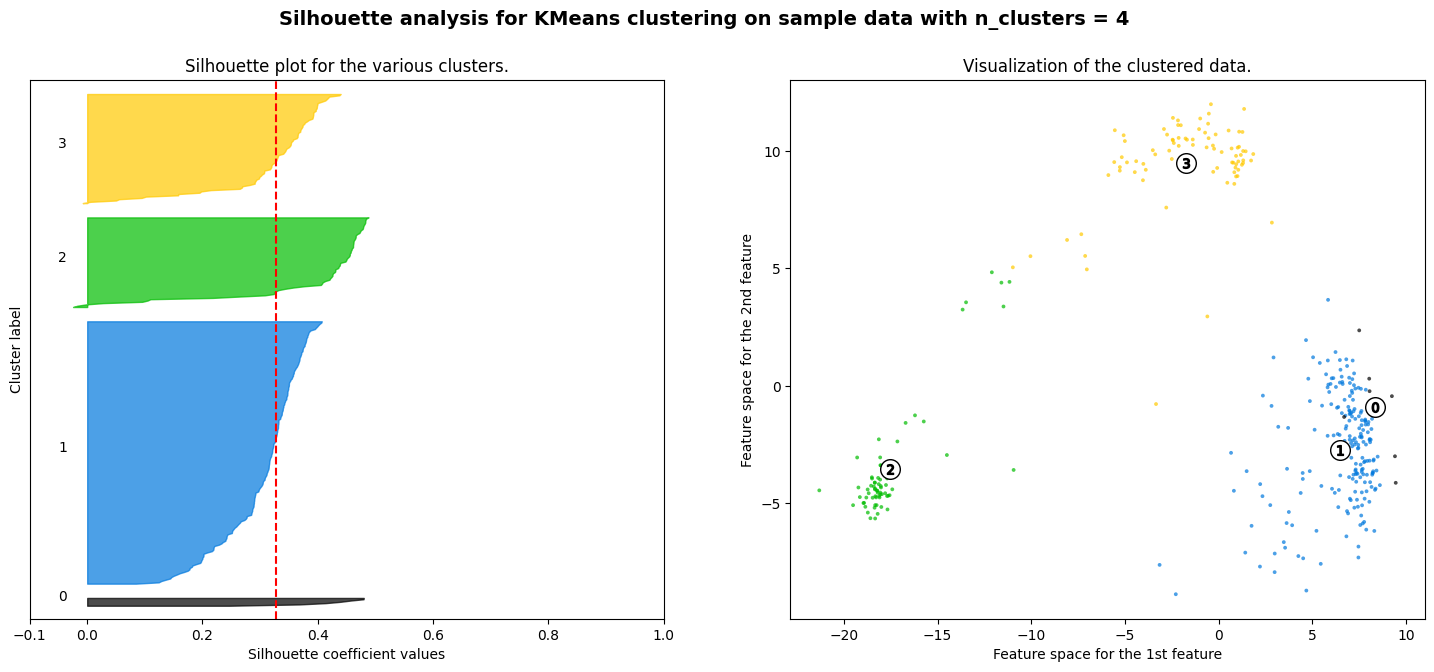

Para n_clusters = 5, silhouette score = 0.35


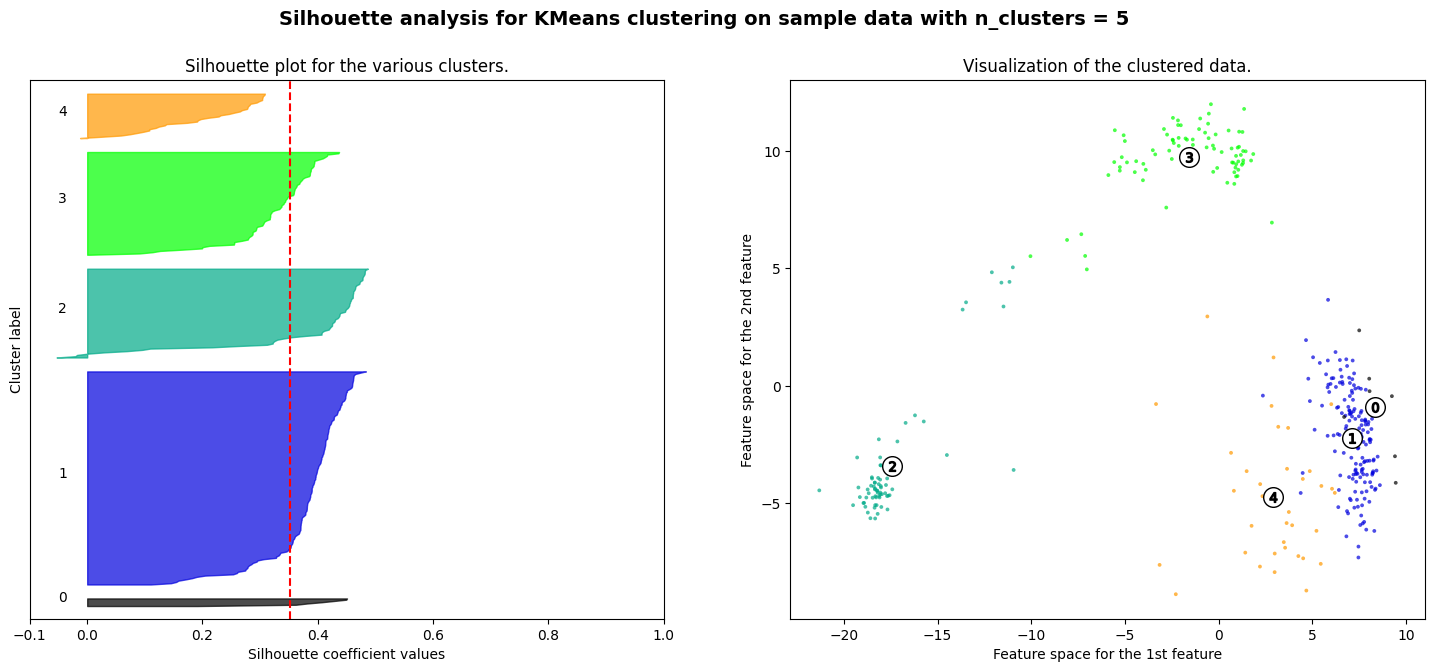

In [17]:
# Calcular Silhouette para k = 2, 3, 4, 5
range_n_clusters = [2, 3, 4, 5]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_pca) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=0)
    cluster_labels = clusterer.fit_predict(X_pca)

    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    print(f"Para n_clusters = {n_clusters}, silhouette score = {silhouette_avg:.2f}")

    sample_silhouette_values = silhouette_samples(X_pca, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0,
                          ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette plot for the various clusters.")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X_pca[:, 0], X_pca[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k")

    centers = clusterer.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker="o", c="white", alpha=1, s=200, edgecolor="k")
    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker=f"${i}$", alpha=1, s=50, edgecolor="k")

    ax2.set_title("Visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {n_clusters}",
                 fontsize=14, fontweight="bold")
    plt.show()

In [18]:
seed = 0
n_clusters = 4

# Euclidean k-means
print("Entrenando Euclidean k-means...")
km_euclidean = TimeSeriesKMeans(
    n_clusters=n_clusters,
    verbose=False,
    random_state=seed
)
y_pred_euclidean = km_euclidean.fit_predict(X_scaled)

# Aplanar X_scaled a 2D para silhouette_score de sklearn
X_flat = X_scaled.reshape(X_scaled.shape[0], -1)

print("Euclidean silhouette: {:.2f}".format(
    silhouette_score(X_flat, y_pred_euclidean, metric="euclidean")))

Entrenando Euclidean k-means...
Euclidean silhouette: 0.30


In [19]:
# DBA k-means (DTW)
print("Entrenando DBA k-means (DTW)...")
km_dtw = TimeSeriesKMeans(
    n_clusters=n_clusters,
    n_init=2,
    metric="dtw",
    verbose=False,
    max_iter_barycenter=10,
    random_state=seed
)
y_pred_dtw = km_dtw.fit_predict(X_scaled)

print("DTW silhouette: {:.2f}".format(
    silhouette_score(X_flat, y_pred_dtw, metric="euclidean")))

Entrenando DBA k-means (DTW)...
DTW silhouette: 0.33


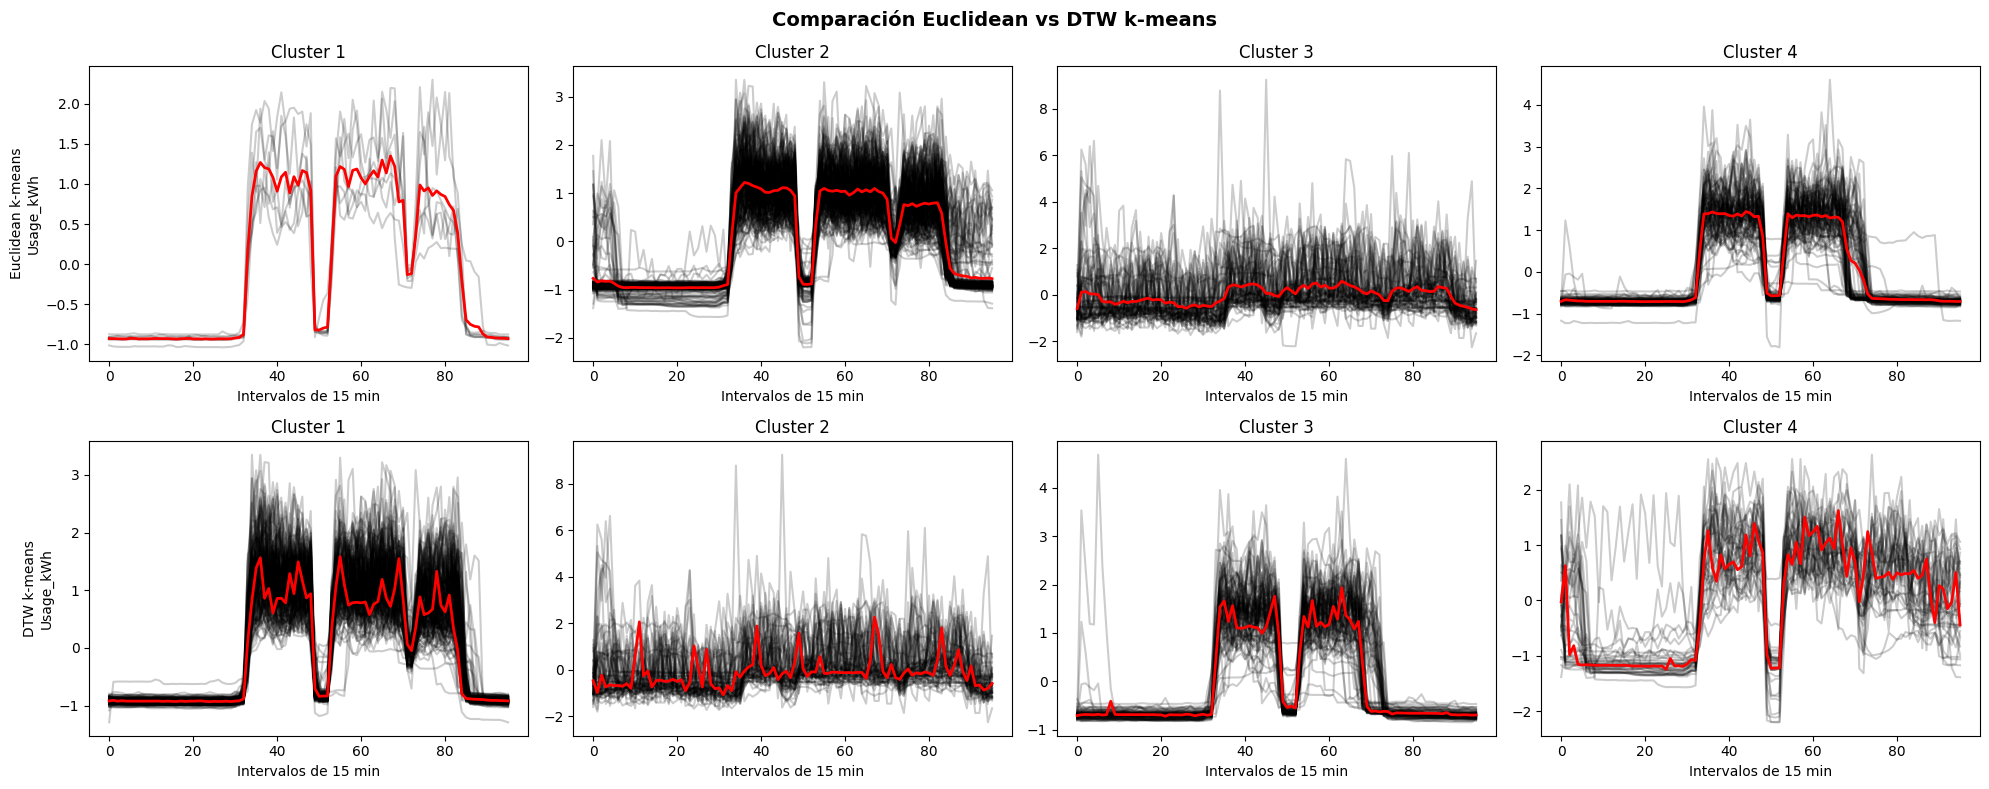

In [20]:
fig, axes = plt.subplots(2, n_clusters, figsize=(20, 8))

# Fila 1 — Euclidean
for yi in range(n_clusters):
    ax = axes[0, yi]
    for xx in X_scaled[y_pred_euclidean == yi]:
        ax.plot(xx[:, 0], "k-", alpha=0.2)
    ax.plot(km_euclidean.cluster_centers_[yi, :, 0], "r-", linewidth=2)
    ax.set_title(f"Cluster {yi + 1}")
    ax.set_xlabel("Intervalos de 15 min")
    if yi == 0:
        ax.set_ylabel("Euclidean k-means\nUsage_kWh")

# Fila 2 — DTW
for yi in range(n_clusters):
    ax = axes[1, yi]
    for xx in X_scaled[y_pred_dtw == yi]:
        ax.plot(xx[:, 0], "k-", alpha=0.2)
    ax.plot(km_dtw.cluster_centers_[yi, :, 0], "r-", linewidth=2)
    ax.set_title(f"Cluster {yi + 1}")
    ax.set_xlabel("Intervalos de 15 min")
    if yi == 0:
        ax.set_ylabel("DTW k-means\nUsage_kWh")

plt.suptitle("Comparación Euclidean vs DTW k-means", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [21]:
# Agregar predicciones al dataframe de etiquetas
etiquetas_dia['cluster_euclidean'] = y_pred_euclidean
etiquetas_dia['cluster_dtw'] = y_pred_dtw

# Ver distribución de Load_Type por cluster (DTW)
print("=== DTW: Load_Type por cluster ===")
print(pd.crosstab(etiquetas_dia['cluster_dtw'],
                  etiquetas_dia['Load_Type']))

=== DTW: Load_Type por cluster ===
Load_Type    Light_Load
cluster_dtw            
0                   179
1                    65
2                    86
3                    35


In [22]:
print("=== DTW: WeekStatus por cluster ===")
print(pd.crosstab(etiquetas_dia['cluster_dtw'],
                  etiquetas_dia['WeekStatus']))

=== DTW: WeekStatus por cluster ===
WeekStatus   Weekday  Weekend
cluster_dtw                  
0                177        2
1                 13       52
2                 40       46
3                 31        4


In [23]:
print("=== DTW: Day_of_week por cluster ===")
print(pd.crosstab(etiquetas_dia['cluster_dtw'],
                  etiquetas_dia['Day_of_week']))

=== DTW: Day_of_week por cluster ===
Day_of_week  Friday  Monday  Saturday  Sunday  Thursday  Tuesday  Wednesday
cluster_dtw                                                                
0                37      37         1       1        41       36         26
1                 2       3        16      36         2        3          3
2                 7       6        32      14         4        5         18
3                 6       7         3       1         5        8          5


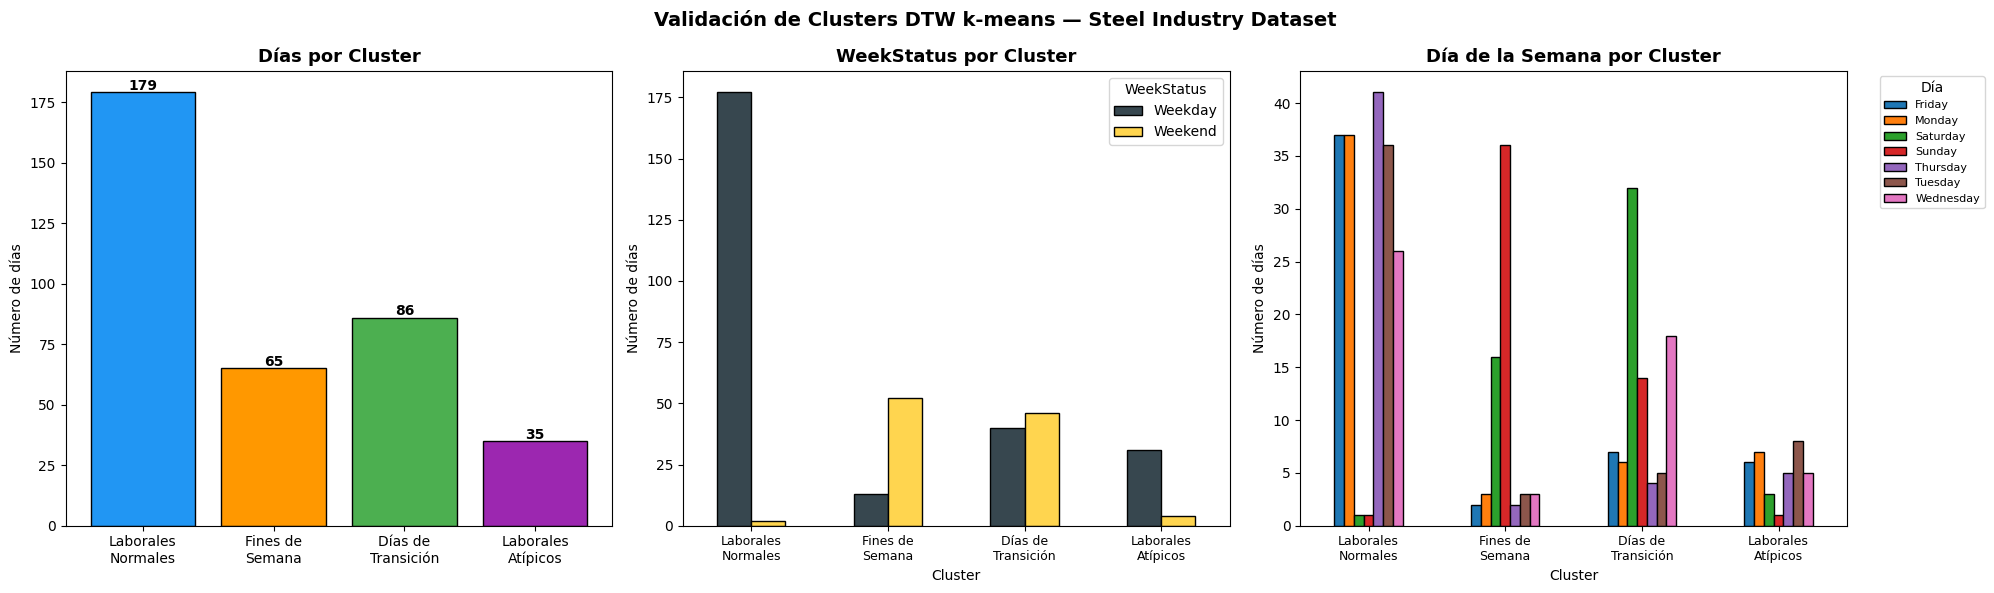

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Etiquetas para los clusters
cluster_nombres = ['Laborales\nNormales', 'Fines de\nSemana', 'Días de\nTransición', 'Laborales\nAtípicos']
colores = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

# --- Gráfica 1: Tamaño de cada cluster ---
cluster_sizes = [sum(y_pred_dtw == i) for i in range(n_clusters)]
axes[0].bar(cluster_nombres, cluster_sizes, color=colores, edgecolor='black')
axes[0].set_title('Días por Cluster', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de días')
for i, v in enumerate(cluster_sizes):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# --- Gráfica 2: WeekStatus por cluster ---
week_data = pd.crosstab(etiquetas_dia['cluster_dtw'], etiquetas_dia['WeekStatus'])
week_data.plot(kind='bar', ax=axes[1], color=['#37474F', '#FFD54F'],
               edgecolor='black', rot=0)
axes[1].set_title('WeekStatus por Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Número de días')
axes[1].set_xticklabels(cluster_nombres, fontsize=9)
axes[1].legend(title='WeekStatus')

# --- Gráfica 3: Día de la semana por cluster ---
day_data = pd.crosstab(etiquetas_dia['cluster_dtw'], etiquetas_dia['Day_of_week'])
day_data.plot(kind='bar', ax=axes[2], edgecolor='black', rot=0)
axes[2].set_title('Día de la Semana por Cluster', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Número de días')
axes[2].set_xticklabels(cluster_nombres, fontsize=9)
axes[2].legend(title='Día', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.suptitle('Validación de Clusters DTW k-means — Steel Industry Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# Codificar WeekStatus a números
le = LabelEncoder()
etiquetas_reales = le.fit_transform(etiquetas_dia['WeekStatus'])

# Adjusted Rand Index para ambos modelos
print("Adjusted Rand Index Euclidean: {:.2f}".format(
    metrics.adjusted_rand_score(etiquetas_reales, y_pred_euclidean)))

print("Adjusted Rand Index DTW: {:.2f}".format(
    metrics.adjusted_rand_score(etiquetas_reales, y_pred_dtw)))

Adjusted Rand Index Euclidean: 0.45
Adjusted Rand Index DTW: 0.35
